# Wybrane Zagadnienia Sztucznej Inteligencji — Zestaw Zaliczeniowy

**WSEI Kraków · semestr letni 2026 · prowadzący: Michał Madejski**

---

## Filozofia tego zestawu

Sześć laboratoriów przeprowadziło Cię od **najprostszego klasyfikatora liniowego** (perceptron) do **sieci pamiętających kontekst** (LSTM). Ten zestaw zaliczeniowy zmusza Cię do **świadomego użycia tych architektur** — każdą na świeżym datasecie z Hugging Face, z porównaniem przed/po.

**Datasety z HF Hub:**
- `sklearn iris` (lokalny w sklearn — używamy do wprowadzenia perceptronu)
- [`zalando-datasets/fashion_mnist`](https://huggingface.co/datasets/zalando-datasets/fashion_mnist) — 70k obrazów 28×28 ubrań (główny image dataset)
- [`uoft-cs/cifar10`](https://huggingface.co/datasets/uoft-cs/cifar10) — 60k obrazów 32×32 RGB
- [`dair-ai/emotion`](https://huggingface.co/datasets/dair-ai/emotion) — 20k tweetów z 6 emocjami

**Reguły:**
1. Każdy lab ma blok: **Teoria → Przykład rozwiązany → Zadanie samodzielne**.
2. Zadania samodzielne **rozszerzają** przykład — ta sama architektura, trudniejszy problem.
3. Cały notebook ma być **uruchamialny od góry do dołu**. Brak ręcznych downloadów.
4. Każde rozwiązanie kończy się **wnioskiem z 2-3 zdań** w komórce Markdown.

**Ocenianie:**
- 50% — poprawność (czy model się uczy, accuracy > baseline)
- 30% — jakość kodu i wizualizacji
- 20% — **insight**: dlaczego twój model radzi sobie tak a nie inaczej? Co byłoby gdybyś zmienił X?

**Acceptance criteria:** każde zadanie ma komentarz z assertem typu "expected: val_acc > 0.85". Te asserty mówią Ci czy implementacja działa.

---

## Mapa zestawu

| # | Lab | Architektura | Dataset | Twoje zadanie | Czas CPU |
|---|-----|--------------|---------|---------------|----------|
| 1 | Perceptron 2D | iris | 2 klasy → wizualizacja granicy | Fashion-MNIST 2 łatwe klasy + wizualizacja wag | < 1 min |
| 2 | Perceptron na obrazach | Fashion-MNIST (T-shirt vs Sneaker) | + porównanie z LogReg | Fashion-MNIST trudna para (Pullover vs Coat) + confusion matrix | < 1 min |
| 3 | MLP + backprop (numpy) | XOR (sigmoid, binarny) | sieć od zera | MLP3 (softmax, 3-class) numpy na Fashion-MNIST | ~3 min |
| 4 | CNN (TensorFlow) | Fashion-MNIST | prosta CNN, 5 epok | CIFAR-10 — porównanie 2 architektur | ~5 min |
| 5 | Augmentacja danych | CIFAR-10 (z aug vs bez) | RandomFlip/Rotation/Zoom | **mini grid** 2×2×2 + 2-fold CV na Fashion-MNIST | ~15 min |
| 6 | RNN/LSTM | sinusoida z szumem | LSTM od zera | LSTM na klasyfikacji emocji w tekście (`dair-ai/emotion`) | ~3 min |

---

## Setup

In [13]:
import os, sys, time, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["HF_DATASETS_DISABLE_PROGRESS_BAR"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

WORKDIR = Path("./_workspace")
WORKDIR.mkdir(exist_ok=True)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"NumPy: {np.__version__}")

TensorFlow: 2.21.0
GPU: False
NumPy: 2.4.5


---

# Lab 1 — Perceptron (klasyfikator liniowy)

## Teoria w trzech zdaniach

**Perceptron** to najprostsza sieć neuronowa: kombinacja liniowa wejść + funkcja progowa. Uczy się przesuwając **hiperpłaszczyznę decyzyjną** w przestrzeni cech tak, by oddzielała klasy.

**Ograniczenie:** działa tylko gdy dane są **liniowo separowalne**. XOR nie jest — i dlatego potrzebujemy warstw ukrytych (Lab 3).

**Reguła aktualizacji:** `w ← w + lr · (y - ŷ) · x`. Klasycznie: jeśli zgadnie dobrze, nie zmienia wag; jeśli źle, przesuwa wagi w stronę poprawy.

## Przykład rozwiązany: iris (2D), wizualizacja granicy decyzji

Test accuracy: 1.000
Wagi: w=[-0.31  0.59], bias=-0.10


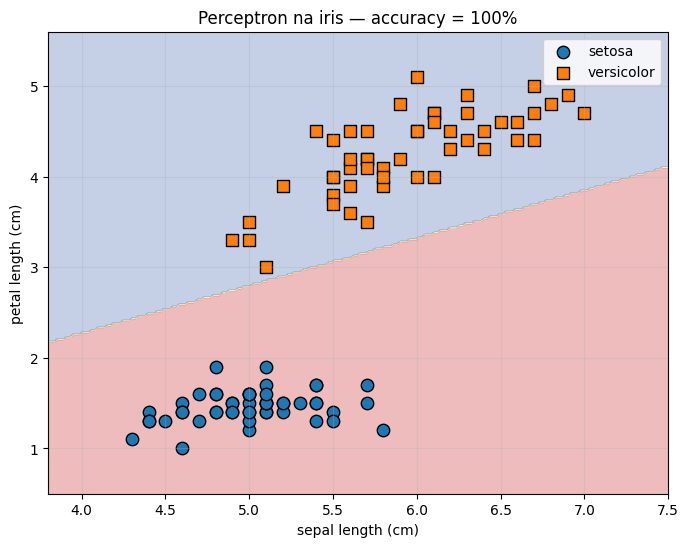


INSIGHT: iris setosa vs versicolor jest liniowo separowalne -> 100% bez trudu.


In [14]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split

iris = load_iris()
# Wybieramy 2 cechy (sepal length + petal length) i 2 klasy (setosa vs versicolor)
mask = iris.target < 2
X = iris.data[mask][:, [0, 2]]  # 2 cechy do wizualizacji
y = iris.target[mask]
feat_names = [iris.feature_names[0], iris.feature_names[2]]
class_names = [iris.target_names[0], iris.target_names[1]]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

clf = Perceptron(max_iter=100, eta0=0.1, random_state=42)
clf.fit(X_tr, y_tr)
acc = clf.score(X_te, y_te)
print(f"Test accuracy: {acc:.3f}")
print(f"Wagi: w={clf.coef_[0]}, bias={clf.intercept_[0]:.2f}")

# Wizualizacja granicy
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlBu")
for cls, marker, label in [(0, "o", class_names[0]), (1, "s", class_names[1])]:
    plt.scatter(X[y == cls, 0], X[y == cls, 1], marker=marker, s=80,
                edgecolor="k", label=label)
plt.xlabel(feat_names[0]); plt.ylabel(feat_names[1])
plt.title(f"Perceptron na iris — accuracy = {acc:.0%}")
plt.legend(); plt.grid(alpha=0.3)
plt.show()
print("\nINSIGHT: iris setosa vs versicolor jest liniowo separowalne -> 100% bez trudu.")

## Zadanie 1.1 — Perceptron na Fashion-MNIST (2 klasy)

**Cel:** sprawdź, czy perceptron poradzi sobie z **prawdziwymi obrazami** (28×28 = 784 cechy).

**Wymagania:**

1. Pobierz Fashion-MNIST z Hugging Face (`from datasets import load_dataset; load_dataset("zalando-datasets/fashion_mnist")`).
2. Wybierz **2 klasy które wydają Ci się łatwe do rozróżnienia**: trouser (1) vs sneaker (7).
3. Spłaszcz obrazy do wektora 784 cech, znormalizuj (`/ 255.0`).
4. Wytrenuj `sklearn.linear_model.Perceptron` (max_iter=50).
5. Ewaluuj na test set: accuracy + confusion matrix.
6. **Wizualizuj wagi** jako obraz 28×28 (`clf.coef_.reshape(28, 28)`) — zobaczysz "szablon" jaki perceptron znalazł.
7. **Bonus:** wyświetl 5 obrazów, które perceptron sklasyfikował błędnie. Co je łączy?

**Wskazówka:** `images = np.array([np.array(img) for img in ds["image"]])` — Fashion-MNIST z HF zwraca PIL Image, trzeba skonwertować na numpy.

Accuracy: 0.9995
[[ 999    1]
 [   0 1000]]


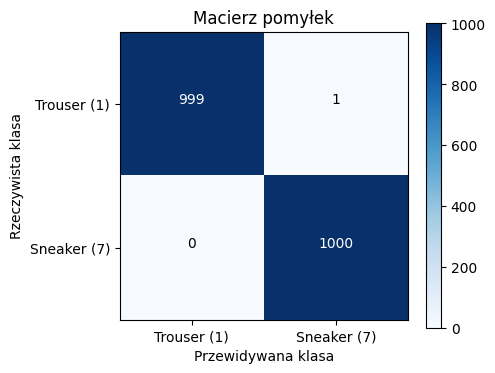

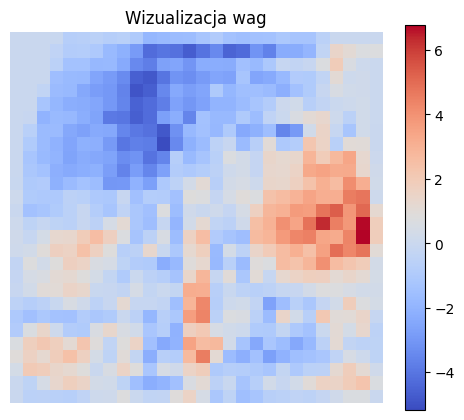

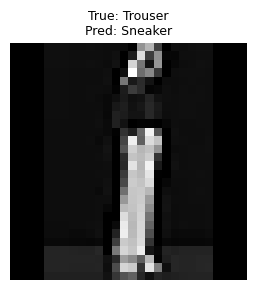

In [15]:
import sys
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix

ds = load_dataset("zalando-datasets/fashion_mnist")

X_train_raw = np.array([np.array(img) for img in ds["train"]["image"]])
y_train_raw = np.array(ds["train"]["label"])

X_test_raw = np.array([np.array(img) for img in ds["test"]["image"]])
y_test_raw = np.array(ds["test"]["label"])

class_A = 1
class_B = 7

train_mask = (y_train_raw == class_A) | (y_train_raw == class_B)
test_mask = (y_test_raw == class_A) | (y_test_raw == class_B)

X_train_filtered = X_train_raw[train_mask]
y_train_filtered = y_train_raw[train_mask]

X_test_filtered = X_test_raw[test_mask]
y_test_filtered = y_test_raw[test_mask]

y_train = np.where(y_train_filtered == class_A, 0, 1)
y_test = np.where(y_test_filtered == class_A, 0, 1)

X_train = X_train_filtered.reshape(X_train_filtered.shape[0], -1) / 255.0
X_test = X_test_filtered.reshape(X_test_filtered.shape[0], -1) / 255.0

clf = Perceptron(max_iter=50, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.title('Macierz pomyłek')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Trouser (1)', 'Sneaker (7)'])
plt.yticks(tick_marks, ['Trouser (1)', 'Sneaker (7)'])
plt.xlabel('Przewidywana klasa')
plt.ylabel('Rzeczywista klasa')
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), horizontalalignment="center", 
                 color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout()
plt.show()

weights_image = clf.coef_.reshape(28, 28)

plt.figure(figsize=(6, 5))
plt.imshow(weights_image, cmap='coolwarm')
plt.colorbar()
plt.title('Wizualizacja wag')
plt.axis('off')
plt.show()

misclassified_indices = np.where(y_pred != y_test)[0]

if len(misclassified_indices) > 0:
    num_to_show = min(5, len(misclassified_indices))
    fig, axes = plt.subplots(1, num_to_show, figsize=(12, 3))
    if num_to_show == 1:
        axes = [axes]
        
    for i, idx in enumerate(misclassified_indices[:num_to_show]):
        img_to_show = X_test_filtered[idx]
        true_label = "Trouser" if y_test[idx] == 0 else "Sneaker"
        pred_label = "Trouser" if y_pred[idx] == 0 else "Sneaker"
        
        axes[i].imshow(img_to_show, cmap='gray')
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=9)
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

---

# Lab 2 — Perceptron na obrazach

## Teoria w trzech zdaniach

**Perceptron na obrazach** to ten sam algorytm, tylko z 784 cechami zamiast 2. Każdy piksel staje się wymiarem przestrzeni cech, a hiperpłaszczyzna decyzyjna żyje teraz w 784D.

**Kluczowa intuicja:** wagi `w_i` mówią, **jak ważny jest piksel i**. Wizualizacja `w.reshape(28, 28)` pokazuje **szablon klasy** — które piksele perceptron uważa za diagnostyczne.

**Ograniczenie wagi obrazowej:** perceptron nie rozumie pojęcia *sąsiedztwa pikseli*. Dla niego piksel (5, 10) i (20, 25) są tak samo niezależne. To dlatego CNN są lepsze — uwzględniają lokalność.

## Przykład rozwiązany: Fashion-MNIST shirt vs sneaker

Train: (2000, 784), Test: (500, 784)
Perceptron       -> train acc: 1.000, test acc: 1.000
LogReg           -> train acc: 1.000, test acc: 1.000


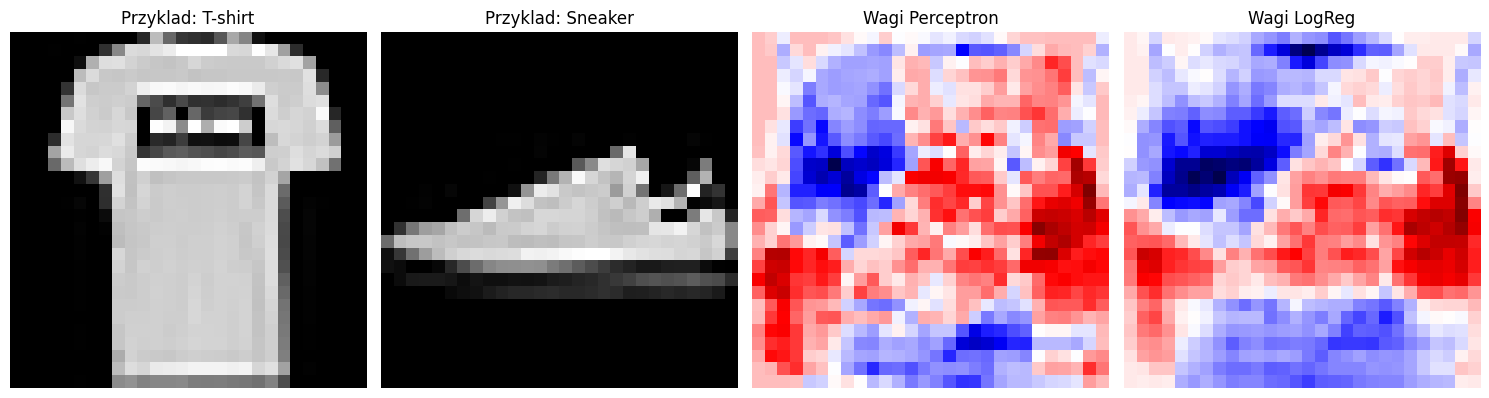


INSIGHT: T-shirt vs Sneaker = bardzo rozne ksztalty -> oba modele ~100%.
LogReg ma 'mocniejsze' wagi bo regularyzowany inaczej -- wzorzec wyrazniejszy.


In [16]:
# Wczytaj Fashion-MNIST raz, dla pozniejszego ponownego uzycia
fashion = load_dataset("zalando-datasets/fashion_mnist")
FASHION_NAMES = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
                 "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

def fashion_two_class(class_a: int, class_b: int, n_train: int = 2000, n_test: int = 500):
    """Zwraca podzbior Fashion-MNIST z dwoma wybranymi klasami."""
    def extract(split, n):
        ds = fashion[split]
        labels = np.array(ds["label"])
        mask = np.isin(labels, [class_a, class_b])
        idx = np.where(mask)[0][:n]
        imgs = np.array([np.array(ds[i]["image"]) for i in idx], dtype=np.float32) / 255.0
        labs = (labels[idx] == class_b).astype(int)  # binaryzacja: a=0, b=1
        return imgs.reshape(len(idx), -1), labs
    return extract("train", n_train), extract("test", n_test)

(X_tr, y_tr), (X_te, y_te) = fashion_two_class(0, 7)  # T-shirt vs Sneaker
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

clf = Perceptron(max_iter=50, eta0=0.01, random_state=42)
clf.fit(X_tr, y_tr)
acc_train = clf.score(X_tr, y_tr)
acc_test = clf.score(X_te, y_te)
print(f"Perceptron       -> train acc: {acc_train:.3f}, test acc: {acc_test:.3f}")

# Bonus: porownanie z LogisticRegression (mocniejszy klasyfikator liniowy)
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(X_tr, y_tr)
print(f"LogReg           -> train acc: {lr.score(X_tr, y_tr):.3f}, test acc: {lr.score(X_te, y_te):.3f}")

# Wizualizacja: oryginaly + wagi obu modeli
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(X_tr[0].reshape(28, 28), cmap="gray")
axes[0].set_title(f"Przyklad: {FASHION_NAMES[0]}")
axes[0].axis("off")
axes[1].imshow(X_tr[np.where(y_tr==1)[0][0]].reshape(28, 28), cmap="gray")
axes[1].set_title(f"Przyklad: {FASHION_NAMES[7]}")
axes[1].axis("off")
axes[2].imshow(clf.coef_.reshape(28, 28), cmap="seismic")
axes[2].set_title(f"Wagi Perceptron")
axes[2].axis("off")
axes[3].imshow(lr.coef_.reshape(28, 28), cmap="seismic")
axes[3].set_title(f"Wagi LogReg")
axes[3].axis("off")
plt.tight_layout()
plt.show()

print("\nINSIGHT: T-shirt vs Sneaker = bardzo rozne ksztalty -> oba modele ~100%.")
print("LogReg ma 'mocniejsze' wagi bo regularyzowany inaczej -- wzorzec wyrazniejszy.")

## Zadanie 2.1 — Trudna para Fashion-MNIST

**Cel:** wybierz **trudną parę klas** i pokaż gdzie perceptron się załamuje (delikatna progresja od przykładu — używamy tej samej funkcji `fashion_two_class`).

**Wymagania:**

1. Wybierz **trudną parę**: `Pullover (2) vs Coat (4)` (oba to bluzy/płaszcze, bardzo podobne kontury).
2. Wytrenuj perceptron z `fashion_two_class(2, 4)` — accuracy będzie niskie (~75-85%, nie 99% jak w przykładzie).
3. Narysuj **confusion matrix** jako heatmap (`plt.imshow` lub `seaborn.heatmap`).
4. Zwizualizuj **5 najbardziej pewnych błędów** — te z największym `|clf.decision_function(x)|` przy złej klasie.
5. **Wniosek (1 komórka Markdown):** dlaczego ta para jest trudna? Czy to wina perceptronu, czy danych?

Perceptron Accuracy: 0.8540
[[843 157]
 [135 865]]


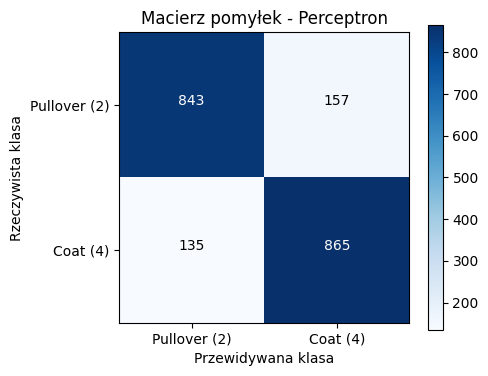

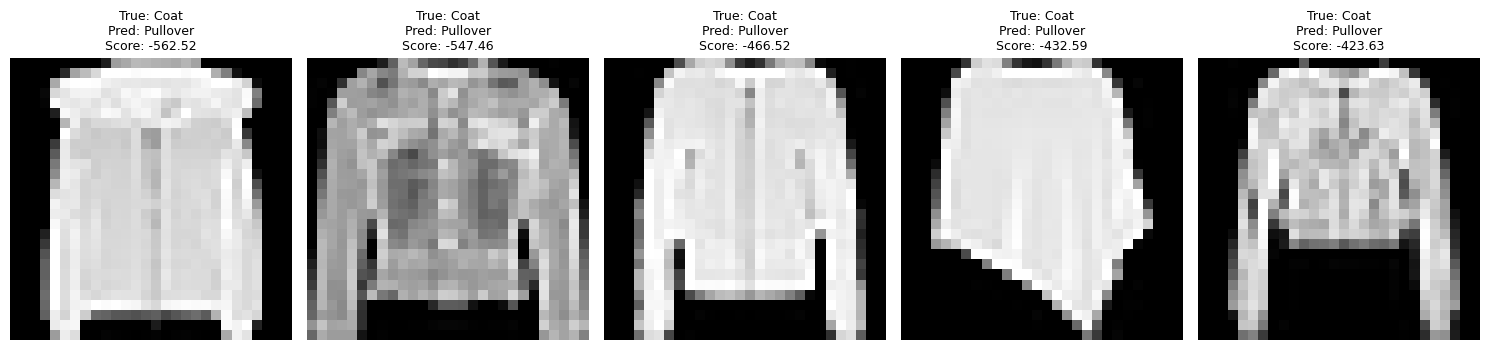

Logistic Regression Accuracy: 0.8505


In [12]:
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

ds = load_dataset("zalando-datasets/fashion_mnist")

X_train_raw = np.array([np.array(img) for img in ds["train"]["image"]])
y_train_raw = np.array(ds["train"]["label"])

X_test_raw = np.array([np.array(img) for img in ds["test"]["image"]])
y_test_raw = np.array(ds["test"]["label"])

class_A = 2
class_B = 4

train_mask = (y_train_raw == class_A) | (y_train_raw == class_B)
test_mask = (y_test_raw == class_A) | (y_test_raw == class_B)

X_train_filtered = X_train_raw[train_mask]
y_train_filtered = y_train_raw[train_mask]

X_test_filtered = X_test_raw[test_mask]
y_test_filtered = y_test_raw[test_mask]

y_train = np.where(y_train_filtered == class_A, 0, 1)
y_test = np.where(y_test_filtered == class_A, 0, 1)

X_train = X_train_filtered.reshape(X_train_filtered.shape[0], -1) / 255.0
X_test = X_test_filtered.reshape(X_test_filtered.shape[0], -1) / 255.0

clf = Perceptron(max_iter=50, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Perceptron Accuracy: {acc:.4f}")

cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.title('Macierz pomyłek - Perceptron')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Pullover (2)', 'Coat (4)'])
plt.yticks(tick_marks, ['Pullover (2)', 'Coat (4)'])
plt.xlabel('Przewidywana klasa')
plt.ylabel('Rzeczywista klasa')
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), horizontalalignment="center", 
                 color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout()
plt.show()

scores = clf.decision_function(X_test)
wrong_mask = (y_pred != y_test)
wrong_indices = np.where(wrong_mask)[0]
wrong_scores_abs = np.abs(scores[wrong_mask])

top_5_wrong_sub_indices = np.argsort(wrong_scores_abs)[-5:][::-1]
top_5_test_indices = wrong_indices[top_5_wrong_sub_indices]

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i, idx in enumerate(top_5_test_indices):
    img_to_show = X_test_filtered[idx]
    true_label = "Pullover" if y_test[idx] == 0 else "Coat"
    pred_label = "Pullover" if y_pred[idx] == 0 else "Coat"
    score_val = scores[idx]
    
    axes[i].imshow(img_to_show, cmap='gray')
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}\nScore: {score_val:.2f}", fontsize=9)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

lr = LogisticRegression(max_iter=100, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")

---

# Lab 3 — MLP + Backpropagation

## Teoria w trzech zdaniach

**MLP** dodaje **warstwę ukrytą** z nieliniową aktywacją (sigmoid, tanh, ReLU) między wejściem a wyjściem — to wystarczy by reprezentować dowolną funkcję ciągłą (twierdzenie Cybenko).

**Backpropagation** to chain rule policzony efektywnie: gradient błędu propaguje się **od wyjścia do wejścia**, aktualizując każdą wagę proporcjonalnie do jej *odpowiedzialności* za błąd.

**Pamiętaj:** forward pass to mnożenia macierzy + aktywacja. Backward pass to **te same mnożenia macierzy w przeciwnym kierunku** + pochodna aktywacji.

## Przykład rozwiązany: XOR z czystego numpy

XOR ground truth: [0. 1. 1. 0.]
MLP predictions:   [0.    0.998 0.998 0.003]
Klasyfikacja po threshold 0.5: [0 1 1 0]


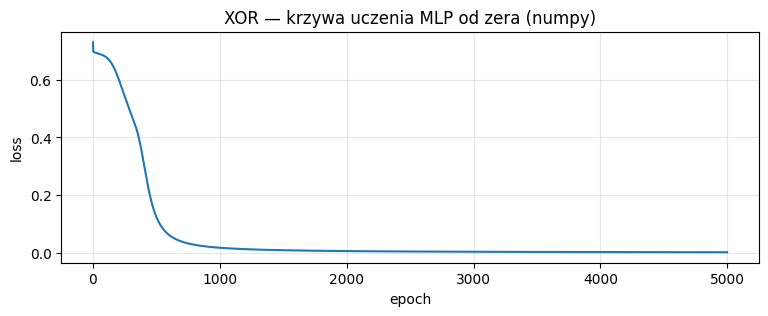

In [17]:
def sigmoid(z): return 1 / (1 + np.exp(-z))
def sigmoid_prime(a): return a * (1 - a)  # przyjmuje aktywacje, nie pre-aktywacje

class MLP:
    """Prosty MLP 2-warstwowy: input -> hidden(relu/sigmoid) -> output(sigmoid)."""
    def __init__(self, n_in, n_hidden, n_out, lr=0.1, seed=42):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(n_in, n_hidden) * np.sqrt(2/n_in)
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.randn(n_hidden, n_out) * np.sqrt(2/n_hidden)
        self.b2 = np.zeros((1, n_out))
        self.lr = lr
    
    def forward(self, X):
        self.X = X
        self.a1 = sigmoid(X @ self.W1 + self.b1)
        self.a2 = sigmoid(self.a1 @ self.W2 + self.b2)
        return self.a2
    
    def backward(self, y):
        m = y.shape[0]
        # output layer
        dZ2 = (self.a2 - y)
        dW2 = self.a1.T @ dZ2 / m
        db2 = dZ2.mean(axis=0, keepdims=True)
        # hidden layer
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * sigmoid_prime(self.a1)
        dW1 = self.X.T @ dZ1 / m
        db1 = dZ1.mean(axis=0, keepdims=True)
        # update
        self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1
    
    def train(self, X, y, epochs=5000):
        losses = []
        for _ in range(epochs):
            out = self.forward(X)
            loss = -np.mean(y * np.log(out + 1e-9) + (1-y) * np.log(1-out + 1e-9))
            losses.append(loss)
            self.backward(y)
        return losses

# XOR
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([[0],[1],[1],[0]], dtype=float)

mlp = MLP(n_in=2, n_hidden=4, n_out=1, lr=1.0)
losses = mlp.train(X_xor, y_xor, epochs=5000)

pred = mlp.forward(X_xor)
print("XOR ground truth:", y_xor.ravel())
print("MLP predictions:  ", np.round(pred.ravel(), 3))
print("Klasyfikacja po threshold 0.5:", (pred.ravel() > 0.5).astype(int))

plt.figure(figsize=(9, 3))
plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("XOR — krzywa uczenia MLP od zera (numpy)")
plt.grid(alpha=0.3)
plt.show()

## Zadanie 3.1 — MLP numpy dla Fashion-MNIST (3 klasy)

**Cel:** wytrenuj **trzywarstwowy MLP od zera w numpy** (bez TensorFlow!) na 3-klasowym problemie obrazowym.

**Wymagania:**

1. Rozszerz klasę `MLP` powyżej o **3 klasy wyjściowe** z softmax + cross-entropy.
2. Wybierz 3 klasy Fashion-MNIST (np. T-shirt, Trouser, Bag = 0, 1, 8).
3. Spłaszcz obrazy do 784, znormalizuj.
4. Trenuj **mini-batch** SGD (batch_size = 64), 30 epok.
5. Pokaż krzywą uczenia (loss + accuracy per epoch) na train i test.
6. Porównaj wynikowe accuracy z `sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(64,))`.
7. **Wniosek:** ile epok i jaki LR działają najlepiej? Co się dzieje gdy `n_hidden = 4` vs `n_hidden = 256`?

**Wskazówka softmax:**
```python
def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))  # numeryczna stabilnosc
    return e / e.sum(axis=1, keepdims=True)
```

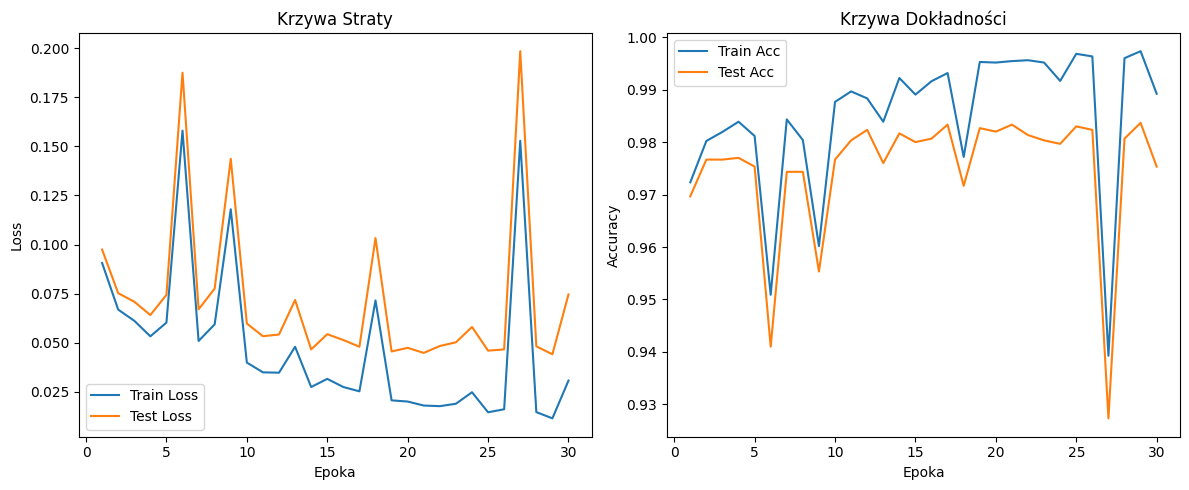

Ostateczne we własnym MLP - Train Acc: 0.9892, Test Acc: 0.9753
Scikit-Learn MLPClassifier - Train Acc: 0.9979, Test Acc: 0.9853


In [18]:
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def relu(z): 
    return np.maximum(0, z)

def relu_prime(z): 
    return (z > 0).astype(float)

class MLP3:
    def __init__(self, n_in: int = 784, n_hidden: int = 64, n_out: int = 3,
                 lr: float = 0.05, seed: int = 42):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(n_in, n_hidden) * np.sqrt(2/n_in)
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.randn(n_hidden, n_out) * np.sqrt(2/n_hidden)
        self.b2 = np.zeros((1, n_out))
        self.lr = lr

    def forward(self, X):
        self.X = X
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = relu(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = softmax(self.Z2)
        return self.A2

    def backward(self, y_onehot):
        m = y_onehot.shape[0]
        dZ2 = (self.A2 - y_onehot) / m
        dW2 = self.A1.T @ dZ2
        db2 = dZ2.sum(axis=0, keepdims=True)
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * relu_prime(self.Z1)
        dW1 = self.X.T @ dZ1
        db1 = dZ1.sum(axis=0, keepdims=True)
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def train_minibatch(self, X_train, y_train_oh, X_test, y_test_oh, epochs=30, batch_size=64):
        history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
        n = len(X_train)
        for ep in range(epochs):
            perm = np.random.permutation(n)
            for i in range(0, n, batch_size):
                idx = perm[i:i+batch_size]
                out = self.forward(X_train[idx])
                if out is None: 
                    return history
                self.backward(y_train_oh[idx])
            
            out_train = self.forward(X_train)
            train_loss = -np.mean(np.sum(y_train_oh * np.log(out_train + 1e-9), axis=1))
            train_acc = (out_train.argmax(axis=1) == y_train_oh.argmax(axis=1)).mean()
            
            out_test = self.forward(X_test)
            test_loss = -np.mean(np.sum(y_test_oh * np.log(out_test + 1e-9), axis=1))
            test_acc = (out_test.argmax(axis=1) == y_test_oh.argmax(axis=1)).mean()
            
            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)
            history["test_loss"].append(test_loss)
            history["test_acc"].append(test_acc)
        return history

ds = load_dataset("zalando-datasets/fashion_mnist")

X_train_raw = np.array([np.array(img) for img in ds["train"]["image"]])
y_train_raw = np.array(ds["train"]["label"])
X_test_raw = np.array([np.array(img) for img in ds["test"]["image"]])
y_test_raw = np.array(ds["test"]["label"])

CLASSES = [0, 1, 8]

train_mask = np.isin(y_train_raw, CLASSES)
test_mask = np.isin(y_test_raw, CLASSES)

X_train_f = X_train_raw[train_mask]
y_train_f = y_train_raw[train_mask]
X_test_f = X_test_raw[test_mask]
y_test_f = y_test_raw[test_mask]

label_map = {0: 0, 1: 1, 8: 2}
y_train_mapped = np.array([label_map[y] for y in y_train_f])
y_test_mapped = np.array([label_map[y] for y in y_test_f])

y_train_oh = np.eye(3)[y_train_mapped]
y_test_oh = np.eye(3)[y_test_mapped]

X_train = X_train_f.reshape(X_train_f.shape[0], -1) / 255.0
X_test = X_test_f.reshape(X_test_f.shape[0], -1) / 255.0

net = MLP3(784, 64, 3, lr=0.1)
hist = net.train_minibatch(X_train, y_train_oh, X_test, y_test_oh, epochs=30, batch_size=64)

epochs_range = range(1, 31)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, hist["train_loss"], label="Train Loss")
plt.plot(epochs_range, hist["test_loss"], label="Test Loss")
plt.xlabel("Epoka")
plt.ylabel("Loss")
plt.title("Krzywa Straty")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, hist["train_acc"], label="Train Acc")
plt.plot(epochs_range, hist["test_acc"], label="Test Acc")
plt.xlabel("Epoka")
plt.ylabel("Accuracy")
plt.title("Krzywa Dokładności")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Ostateczne we własnym MLP - Train Acc: {hist['train_acc'][-1]:.4f}, Test Acc: {hist['test_acc'][-1]:.4f}")

clf = MLPClassifier(hidden_layer_sizes=(64,), activation='relu', solver='sgd', 
                    batch_size=64, learning_rate_init=0.1, max_iter=30, random_state=42)
clf.fit(X_train, y_train_mapped)
sk_train_acc = accuracy_score(y_train_mapped, clf.predict(X_train))
sk_test_acc = accuracy_score(y_test_mapped, clf.predict(X_test))
print(f"Scikit-Learn MLPClassifier - Train Acc: {sk_train_acc:.4f}, Test Acc: {sk_test_acc:.4f}")

---

# Lab 4 — CNN w TensorFlow

## Teoria w trzech zdaniach

**Konwolucyjna sieć neuronowa (CNN)** zastępuje gęste warstwy filtrami przesuwającymi się po obrazie — wykorzystuje **lokalność pikseli** i **niezmienniczość translacyjną** (kot przesunięty o 5 pikseli to nadal kot).

**Typowy blok CNN:** `Conv → BatchNorm → ReLU → MaxPool → Dropout`. Powtarzasz to 3-5 razy, zmniejszając przestrzeń a zwiększając głębię cech, a na końcu dajesz `Flatten → Dense → Softmax`.

**Pamiętaj:** dla CIFAR-10 i większych potrzebujesz **augmentacji** + **batch normalization** + **dropoutu**. Bez tego sieć overfituje na 3-5 epokach.

## Przykład rozwiązany: prosta CNN na Fashion-MNIST

In [19]:
# Wczytaj Fashion-MNIST do tablic numpy (z HF datasets)
def fashion_full_split():
    train_imgs = np.array([np.array(img) for img in fashion["train"]["image"]], dtype=np.float32) / 255.0
    train_labs = np.array(fashion["train"]["label"])
    test_imgs = np.array([np.array(img) for img in fashion["test"]["image"]], dtype=np.float32) / 255.0
    test_labs = np.array(fashion["test"]["label"])
    return (train_imgs[..., None], train_labs), (test_imgs[..., None], test_labs)

# Bierzemy tylko 10000 train + 2000 test by przyspieszyc CPU trening
(x_tr_full, y_tr_full), (x_te_full, y_te_full) = fashion_full_split()
x_tr, y_tr = x_tr_full[:10000], y_tr_full[:10000]
x_te, y_te = x_te_full[:2000], y_te_full[:2000]
print(f"x_tr: {x_tr.shape}, y_tr: {y_tr.shape}")
print(f"x_te: {x_te.shape}, y_te: {y_te.shape}")

def small_cnn(input_shape, n_classes):
    return keras.Sequential([
        layers.Input(input_shape),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])

tf.random.set_seed(42)
model = small_cnn((28, 28, 1), 10)
model.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])
hist = model.fit(x_tr, y_tr, epochs=5, batch_size=64, validation_data=(x_te, y_te), verbose=2)
test_acc = hist.history["val_accuracy"][-1]
print(f"\nFinal test accuracy: {test_acc:.3f}")

x_tr: (10000, 28, 28, 1), y_tr: (10000,)
x_te: (2000, 28, 28, 1), y_te: (2000,)
Epoch 1/5


ValueError: dtype='string' is not a valid dtype for Keras type promotion.

## Zadanie 4.1 — CNN na CIFAR-10 (porównaj 2 architektury)

**Cel:** zbuduj **dwie architektury CNN** dla CIFAR-10 i porównaj je rzetelnie.

**Wymagania:**

1. Pobierz CIFAR-10 z HF (`load_dataset("uoft-cs/cifar10")`).
2. Użyj 10000 train + 2000 test (subset dla rozsądnego czasu treningu na CPU).
3. **Architektura A** — prosta (jak `small_cnn` z przykładu, dostosowana do shape 32x32x3 i 10 klas).
4. **Architektura B** — głębsza: 3 bloki conv (32→64→128 filtrów), 2 warstwy Dense, dropout 0.5.
5. Trenuj obie po 8 epok, mierz czas każdej. 
6. Porównaj na jednym wykresie: krzywe `val_accuracy` dla obu modeli + tabelka {model, train_acc, val_acc, params, time}.
7. **Wniosek:** czy głębsza sieć była zawsze lepsza? Kiedy się to opłaca?

In [20]:
import time
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from datasets import load_dataset
from tensorflow import keras
from tensorflow.keras import layers

cifar = load_dataset("uoft-cs/cifar10")

x_tr_raw = np.array([np.array(img) for img in cifar["train"]["img"]], dtype=np.float32) / 255.0
y_tr_raw = np.array(cifar["train"]["label"], dtype=np.int32)

x_te_raw = np.array([np.array(img) for img in cifar["test"]["img"]], dtype=np.float32) / 255.0
y_te_raw = np.array(cifar["test"]["label"], dtype=np.int32)

x_tr, y_tr = x_tr_raw[:10000], y_tr_raw[:10000]
x_te, y_te = x_te_raw[:2000], y_te_raw[:2000]

def make_model_A(input_shape=(32, 32, 3), n_classes=10):
    return keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])

def make_model_B(input_shape=(32, 32, 3), n_classes=10):
    return keras.Sequential([
        layers.Input(shape=input_shape),
        
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(128, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])

tf.random.set_seed(42)
model_A = make_model_A()
model_A.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])

start_time = time.time()
hist_A = model_A.fit(x_tr, y_tr, epochs=8, batch_size=64, validation_data=(x_te, y_te), verbose=1)
time_A = time.time() - start_time

tf.random.set_seed(42)
model_B = make_model_B()
model_B.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])

start_time = time.time()
hist_B = model_B.fit(x_tr, y_tr, epochs=8, batch_size=64, validation_data=(x_te, y_te), verbose=1)
time_B = time.time() - start_time

plt.figure(figsize=(8, 5))
plt.plot(range(1, 9), hist_A.history["val_accuracy"], label="Model A (Prosty) - Val Acc", marker='o')
plt.plot(range(1, 9), hist_B.history["val_accuracy"], label="Model B (Głęboki) - Val Acc", marker='s')
plt.xlabel("Epoka")
plt.ylabel("Validation Accuracy")
plt.title("Porównanie krzywych val_accuracy")
plt.legend()
plt.grid(True)
plt.show()

params_A = model_A.count_params()
params_B = model_B.count_params()

train_acc_A = hist_A.history["accuracy"][-1]
val_acc_A = hist_A.history["val_accuracy"][-1]

train_acc_B = hist_B.history["accuracy"][-1]
val_acc_B = hist_B.history["val_accuracy"][-1]

print(f"\n{'Model':<10} | {'Train Acc':<10} | {'Val Acc':<10} | {'Params':<12} | {'Time (s)':<10}")
print("-" * 60)
print(f"{'Model A':<10} | {train_acc_A:<10.4f} | {val_acc_A:<10.4f} | {params_A:<12,} | {time_A:<10.2f}")
print(f"{'Model B':<10} | {train_acc_B:<10.4f} | {val_acc_B:<10.4f} | {params_B:<12,} | {time_B:<10.2f}")

Epoch 1/8


ValueError: dtype='string' is not a valid dtype for Keras type promotion.

---

# Lab 5 — Augmentacja danych

## Teoria w trzech zdaniach

**Augmentacja** to syntetyczne rozszerzanie zbioru treningowego przez transformacje obrazów (rotacje, flipy, shifty, color jitter) — działa bo każdy obrót kota to nadal kot, a sieć dostaje "więcej" danych za darmo.

**Reguła:** augmentacja musi być **realistyczna**. Flip pionowy ma sens dla kotów, ale nie dla cyfr ("6" odwrócone to "9"). Mocny color shift ma sens dla outdoor scenes, ale nie dla medycyny.

**`ImageDataGenerator` to klasyk Keras, ale w TF 2.6+ preferowany jest `tf.keras.layers.Random*`** — augmentacja jako część grafu modelu, akcelerowana na GPU.

## Przykład rozwiązany: CIFAR-10 z ImageDataGenerator vs bez

In [21]:
# Pobierz CIFAR-10 (mniejszy subset by zmiescic w czasie)
cifar = load_dataset("uoft-cs/cifar10")
def cifar_subset(n_train=5000, n_test=1000):
    tr_imgs = np.array([np.array(img) for img in cifar["train"]["img"][:n_train]], dtype=np.float32) / 255.0
    tr_labs = np.array(cifar["train"]["label"][:n_train])
    te_imgs = np.array([np.array(img) for img in cifar["test"]["img"][:n_test]], dtype=np.float32) / 255.0
    te_labs = np.array(cifar["test"]["label"][:n_test])
    return (tr_imgs, tr_labs), (te_imgs, te_labs)

(x_tr, y_tr), (x_te, y_te) = cifar_subset()
print(f"CIFAR train: {x_tr.shape}, test: {x_te.shape}")

def cifar_cnn():
    return keras.Sequential([
        layers.Input((32, 32, 3)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])

# Bez augmentacji
tf.random.set_seed(42)
m1 = cifar_cnn()
m1.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])
h1 = m1.fit(x_tr, y_tr, epochs=8, batch_size=64, validation_data=(x_te, y_te), verbose=0)
print(f"Bez augmentacji: val_acc = {h1.history['val_accuracy'][-1]:.3f}")

# Z augmentacja jako warstwy modelu (nowoczesny sposob)
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])
tf.random.set_seed(42)
m2 = keras.Sequential([augment, cifar_cnn()])
m2.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])
h2 = m2.fit(x_tr, y_tr, epochs=8, batch_size=64, validation_data=(x_te, y_te), verbose=0)
print(f"Z augmentacja:    val_acc = {h2.history['val_accuracy'][-1]:.3f}")

# Wykres
plt.figure(figsize=(10, 4))
plt.plot(h1.history["val_accuracy"], "o-", label="bez augmentacji")
plt.plot(h2.history["val_accuracy"], "s-", label="z augmentacja")
plt.xlabel("epoka"); plt.ylabel("val_accuracy")
plt.title("CIFAR-10: wpływ augmentacji")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

CIFAR train: (5000, 32, 32, 3), test: (1000, 32, 32, 3)


ValueError: dtype='string' is not a valid dtype for Keras type promotion.

## Zadanie 5.1 — Optymalna augmentacja dla Fashion-MNIST (mini grid search)

**Cel:** znajdź **dobrą kombinację augmentacji** dla Fashion-MNIST metodą grid search z cross-walidacją — **w czasie pozwalającym ukończyć zadanie na laptopie** (~15 min CPU).

**Wymagania:**

1. Bierzemy **4000 obrazów** z Fashion-MNIST (10 klas).
2. Mini grid (8 konfiguracji):
   - `rotation` ∈ {0.0, 0.15}
   - `zoom` ∈ {0.0, 0.15}
   - `flip` ∈ {None, "horizontal"}
3. **2-fold CV** (sklearn `KFold(n_splits=2)`).
4. **3 epoki** treningu CNN per fold (krótko, dla speedu).
5. Raportuj **średnie val_accuracy** dla każdej konfiguracji.
6. Wybierz top 3 konfiguracje, narysuj wykres słupkowy.
7. **Wniosek:** która augmentacja najbardziej pomogła? Czy flip poziomy zaszkodził w jakiejś klasie (sprawdź na confusion matrix dla flip=horizontal)?

**Szacowany czas:** 8 configs × 2 folds × 3 epoki × 2000 train images ≈ **15 min CPU**.

**Wskazówka:**
```python
from sklearn.model_selection import KFold
kf = KFold(n_splits=2, shuffle=True, random_state=42)
for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    aug = keras.Sequential([layers.RandomRotation(0.15), layers.RandomZoom(0.15)])
    model = keras.Sequential([aug, small_cnn((28,28,1), 10)])
    model.compile(...)
    model.fit(X[tr_idx], y[tr_idx], epochs=3, validation_data=(X[val_idx], y[val_idx]))
```

In [22]:
import itertools
import numpy as np
import tensorflow as tf
from datasets import load_dataset
from sklearn.model_selection import KFold
from tensorflow import keras
from tensorflow.keras import layers

fashion = load_dataset("fashion_mnist")

x_tr_full = np.array([np.array(img) for img in fashion["train"]["image"]], dtype=np.float32) / 255.0
y_tr_full = np.array(fashion["train"]["label"], dtype=np.int32)
x_tr_full = x_tr_full[..., None]

N_FASHION = 4000
X_fmnist = x_tr_full[:N_FASHION]
y_fmnist = y_tr_full[:N_FASHION]

grid = list(itertools.product(
    [0.0, 0.15],
    [0.0, 0.15],
    [None, "horizontal"]
))

print(f"Liczba konfiguracji do testu: {len(grid)}")

def build_aug_pipeline(rot: float, zoom: float, flip: str | None):
    layers_list = []
    if flip is not None:
        layers_list.append(layers.RandomFlip(flip))
    if rot > 0:
        layers_list.append(layers.RandomRotation(rot))
    if zoom > 0:
        layers_list.append(layers.RandomZoom(zoom))
    return keras.Sequential(layers_list) if layers_list else None

def small_fashion_cnn():
    return keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(16, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])

kf = KFold(n_splits=2, shuffle=True, random_state=42)
results = {}

for rot, zoom, flip in grid:
    fold_accs = []
    print(f"\nTestowanie konfiguracji: rot={rot}, zoom={zoom}, flip={flip}")
    
    for tr_idx, val_idx in kf.split(X_fmnist):
        aug = build_aug_pipeline(rot, zoom, flip)
        base = small_fashion_cnn()
        
        if aug is not None:
            model = keras.Sequential([aug, base])
        else:
            model = base
            
        model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        
        hist = model.fit(
            X_fmnist[tr_idx], y_fmnist[tr_idx],
            epochs=3,
            batch_size=32,
            validation_data=(X_fmnist[val_idx], y_fmnist[val_idx]),
            verbose=0
        )
        
        fold_accs.append(hist.history["val_accuracy"][-1])
        
    mean_acc = float(np.mean(fold_accs))
    results[(rot, zoom, flip)] = mean_acc
    print(f"-> Sredni Val Acc: {mean_acc:.3f}")

sorted_results = sorted(results.items(), key=lambda item: item[1], reverse=True)

print("\n=== RANKING TOP 3 KONFIGURACJI ===")
for i, (config, acc) in enumerate(sorted_results[:3]):
    print(f"{i+1}. Rot: {config[0]}, Zoom: {config[1]}, Flip: {config[2]} -> Srednia dokladnosc: {acc:.4f}")

HfUriError: Invalid HF URI 'hf://datasets/fashion_mnist@531be5e2ccc9dba0c201ad3ae567a4f3d16ecdd2/.huggingface.yaml'. Repository id must be 'namespace/name', got 'fashion_mnist'.

---

# Lab 6 — RNN i LSTM

## Teoria w trzech zdaniach

**Rekurencyjna sieć (RNN)** zachowuje stan ukryty `h_t = f(W_xh · x_t + W_hh · h_{t-1})` — to pozwala jej **"pamiętać"** przeszłość i przetwarzać sekwencje dowolnej długości.

**Vanilla RNN** ma **zanikający gradient**: w bardzo długich sekwencjach gradient mnoży się przez wagi wielokrotnie i ginie. **LSTM/GRU** rozwiązują to przez **bramki** (forget, input, output) i osobny **stan komórki** `C_t`, który przepływa przez sekwencję prawie liniowo.

**Pamiętaj:** dla NLP w 2026 standardem są **Transformery** (BERT, GPT). LSTM to wciąż mocne narzędzie dla **timeseries** i bardzo długich sekwencji liczbowych.

## Przykład rozwiązany: LSTM przewiduje sinusoidę z szumem

Train: (776, 30, 1), Test: (194, 30, 1)
Final val_loss: 0.0111


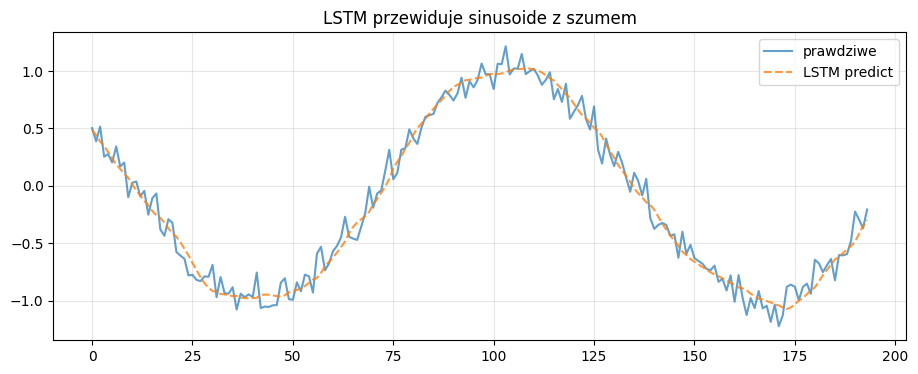

In [4]:
# Generuj synthetic timeseries: sinus + szum
np.random.seed(42)
T = 1000
t = np.linspace(0, 50, T)
y = np.sin(t) + 0.1 * np.random.randn(T)

# Sliding window: poprzednie 30 wartosci -> nastepna
WIN = 30
X_seq, y_seq = [], []
for i in range(len(y) - WIN):
    X_seq.append(y[i:i+WIN])
    y_seq.append(y[i+WIN])
X_seq = np.array(X_seq).reshape(-1, WIN, 1)
y_seq = np.array(y_seq)

# Train/test split (chronologiczny -- NIE shuffle!)
split = int(0.8 * len(X_seq))
X_tr, X_te = X_seq[:split], X_seq[split:]
y_tr, y_te = y_seq[:split], y_seq[split:]
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

tf.random.set_seed(42)
model_lstm = keras.Sequential([
    layers.Input((WIN, 1)),
    layers.LSTM(32),
    layers.Dense(1),
])
model_lstm.compile("adam", "mse")
hist = model_lstm.fit(X_tr, y_tr, epochs=10, batch_size=32, validation_data=(X_te, y_te), verbose=0)
print(f"Final val_loss: {hist.history['val_loss'][-1]:.4f}")

# Predykcja
y_pred = model_lstm.predict(X_te, verbose=0).ravel()
plt.figure(figsize=(11, 4))
plt.plot(y_te, label="prawdziwe", alpha=0.7)
plt.plot(y_pred, label="LSTM predict", alpha=0.8, linestyle="--")
plt.title("LSTM przewiduje sinusoide z szumem")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Zadanie 6.1 — LSTM dla klasyfikacji emocji w tekście

**Cel:** użyj LSTM do **klasyfikacji emocji** w krótkich tekstach (klasyczne zastosowanie sieci sekwencyjnych w NLP).

**Wymagania:**

1. Pobierz dataset `dair-ai/emotion` z HF (`load_dataset("dair-ai/emotion")`). Ma 16k train + 2k test, 6 klas (sadness, joy, love, anger, fear, surprise).
2. **Tokenizacja:** użyj `keras.layers.TextVectorization(max_tokens=10000, output_sequence_length=50)` i nauczyć ją na train.
3. **Architektura:** `Embedding(10000, 64) → LSTM(64) → Dropout(0.5) → Dense(6, softmax)`.
4. Trenuj 10 epok, batch_size=64.
5. Wykres: train/val accuracy + loss.
6. Confusion matrix na test set.
7. Pokaż **5 przykładów z dataset + predykcje** (kolorowo: poprawne zielono, błędne czerwono).
8. **Wniosek:** które emocje są najtrudniejsze do rozróżnienia? Dlaczego?

**Wskazówka — vectorize input:**
```python
vectorizer = keras.layers.TextVectorization(max_tokens=10000, output_sequence_length=50)
vectorizer.adapt(train_texts)  # uczy slownik
X_train_ids = vectorizer(train_texts).numpy()  # teksty -> sekwencje id tokenow
```

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

tf.random.set_seed(42)
np.random.seed(42)

print("Pobieranie zbioru danych...")
dataset = load_dataset("dair-ai/emotion")

train_texts = dataset['train']['text']
train_labels = np.array(dataset['train']['label'])

test_texts = dataset['test']['text']
test_labels = np.array(dataset['test']['label'])

class_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

max_tokens = 10000
output_sequence_length = 50

vectorizer = layers.TextVectorization(
    max_tokens=max_tokens,
    output_sequence_length=output_sequence_length
)
vectorizer.adapt(train_texts)

X_train = vectorizer(train_texts).numpy()
X_test = vectorizer(test_texts).numpy()

model = keras.Sequential([
    layers.Input(shape=(output_sequence_length,)),
    layers.Embedding(input_dim=max_tokens, output_dim=64, input_length=output_sequence_length),
    layers.LSTM(64),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

print("\nRozpoczynanie trenowania...")
history = model.fit(
    X_train, train_labels,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Pobieranie zbioru danych...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,414 (2.57 MB)

 Trainable params: 673,414 (2.57 MB)

 Non-trainable params: 0 (0.00 B)


Rozpoczynanie trenowania...
Epoch 1/10


---

# Sekcja kontrolna — co umiesz po tym zestawie

Po ukończeniu wszystkich 6 zadań powinieneś **bez przygotowania** odpowiedzieć na:

1. **Perceptron:** dlaczego nie nauczy się XOR? Co geometrycznie znaczy *liniowa separowalność*?
2. **MLP:** ile warstw ukrytych potrzeba do XOR i dlaczego? Co znaczy uniwersalny approximator?
3. **Backprop:** który gradient pierwszy się liczy — wejście czy wyjście? Dlaczego mówimy "backward"?
4. **CNN:** co znaczy "convolutional" — co rozróżnia ten typ warstwy od Dense?
5. **Augmentacja:** dlaczego nigdy nie augmentujemy zbioru testowego?
6. **LSTM:** jaką informację niesie stan ukryty `h_t`, a jaką stan komórki `C_t`? Dlaczego dwa?

## Co dalej?

- **Transfer learning:** pretrained ResNet/EfficientNet → twój problem. Często mniej kodu + lepsze wyniki niż trening od zera.
- **Transformery:** [HuggingFace course](https://huggingface.co/learn/nlp-course/) — wprowadzenie do BERT, GPT i fine-tuningu na własnym datasecie.
- **Praktyka:** Kaggle competitions to najszybsza droga do mistrzostwa. Zacznij od kategorii "Getting Started".
- **Theory deep dive:** ["Deep Learning" Goodfellow et al.](https://www.deeplearningbook.org/) — darmowa, kompletna, do trzymania pod ręką.

In [ ]:
# Sprzatanie / podsumowanie
print(f"Workspace: {WORKDIR.resolve()}")
print("Zestaw zaliczeniowy ukonczony. Powodzenia w karierze!")